# TASK5 AI交易引擎：机器学习算法与场景应用

对于本题的第一次尝试首先使用了真实交易数据，但是评估结果并不理想，因此并没有作为主要报告的内容，后文将在第四节思考评估这段经历。报告选用了scikit-learn 乳腺癌数据集来完成概念解释、特征工程以及模型评估结果分析。

## 一、分类型机器学习算法

分类模型适合处理结果只有有限类别的问题。在乳腺癌数据中，恶性记为1，良性记为0，模型先估计每例样本属于恶性的概率，再按照给定阈值转换成具体类别。概率可以用来比较样本的风险顺序，类别结果则可以进一步统计漏判和误判的数量。

**逻辑回归。** 逻辑回归先计算各项特征的线性组合，再用 Sigmoid 函数把结果转换到0和1之间，从而得到样本属于正类的概率。下面公式中的 $X_1$ 至 $X_p$ 表示输入特征，$\beta_0$ 至 $\beta_p$ 表示模型根据训练样本估计的参数。

$$P(Y=1\mid X)=\frac{1}{1+\exp[-(\beta_0+\beta_1X_1+\cdots+\beta_pX_p)]}$$

特征完成标准化以后，逻辑回归系数的正负可以表示变量与恶性概率之间的方向，绝对值可以比较同一模型中不同变量的影响大小。逻辑回归结构简单，结果容易解释，因此常被用作分类任务的基准模型；如果数据中存在复杂阈值或特征交互，线性形式可能无法完整表达这些关系。

**决策树。** 决策树通过反复寻找特征和切分点，把样本逐步分到不同叶节点，因此能够表达非线性阈值以及变量之间的组合关系。树的分类规则可以沿着节点路径直接查看，解释起来比较直观；树深过大时也容易记住训练样本中的偶然差异，所以训练时通常会限制最大深度和叶节点的最小样本数。

**随机森林。** 随机森林会对样本和特征重复抽样，在不同子样本上训练多棵决策树，最后平均各棵树给出的概率。单棵树容易受到某些样本影响，多棵树集成后可以降低这种波动，因此随机森林通常比一棵决策树稳定。不过，模型仍然只能利用原始特征中已经存在的信息，增加树的数量不会自动产生新的预测信号。

**梯度提升。** 梯度提升按照顺序训练多棵浅树，后一棵树继续修正前面模型没有处理好的样本，因此能够逐步拟合较细的非线性关系。它的结果会受到树深、学习率和树数影响，在样本量较小时，大范围搜索参数容易把训练集中的波动当成有效规律。本题只比较有限的参数组合，以控制过度拟合。

## 二、机器学习模型评价指标

### 2.1 混淆矩阵

混淆矩阵的含义取决于正类的定义，本题将恶性设为正类。TP表示正确识别的恶性样本，FN表示被漏判为良性的恶性样本，FP表示被误判为恶性的良性样本，TN表示正确识别的良性样本。Accuracy计算全部样本中判断正确的比例，Precision考察预测为恶性的样本中有多少确实恶性，Recall考察实际恶性样本中有多少被模型识别，Specificity则计算良性样本的正确识别率。F1综合Precision和Recall，Balanced Accuracy对两类识别率取平均，在类别比例存在差异时比单独使用Accuracy更稳妥。

### 2.2 ROC曲线与AUC

ROC曲线记录概率阈值逐步变化时假阳性率和真阳性率的组合，横轴是假阳性率，纵轴是真阳性率。AUC是ROC曲线下面积，也可以理解为随机抽取一例恶性和一例良性时，模型把恶性样本排在更高位置的概率。AUC等于0.5时，排序结果接近随机；AUC等于1时，两类样本可以完全分开。AUC反映全部阈值下的总体排序能力，混淆矩阵反映某一个阈值下的错判结构，因此模型评估时需要结合两类结果。

## 三、Python编程实现

| 步骤 | 本次作答 |
|---|---|
| 1. 准备数据 | 加载乳腺癌数据，核对样本数、缺失、重复和标签 |
| 2. 构造标签 | 将原标签重编码为恶性=1、良性=0 |
| 3. 划分样本 | 患者样本按分层随机方式划分80%训练集和20%测试集 |
| 4. 选择特征 | 只用训练集检查类别关联、折间稳定性、相关性和VIF |
| 5. 训练 | 比较逻辑回归、决策树、随机森林和梯度提升 |
| 6. 预测 | 输出恶性概率和0.5阈值下的类别 |
| 7. 评估 | 计算AUC、ROC、PR-AUC、混淆矩阵和常用指标 |
| 8. 特征解释 | 报告逻辑回归系数以及树模型的特征重要性 |
| 9. 保存结果 | 保存冻结数据、筛选记录、模型、预测、指标和图表 |

### 3.0 环境与参数

In [1]:
from pathlib import Path
import json, sys, warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd().resolve()
if ROOT.name == "Task5":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "Task5" / "scripts"))
from cancer_case_analysis import FEATURE_NAMES, MODEL_NAMES, RESULT_DIR, MODEL_DIR, run_and_save

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.sans-serif": ["Songti SC", "SimSun", "Arial Unicode MS", "DejaVu Sans"],
    "axes.unicode_minus": False, "figure.dpi": 130, "savefig.dpi": 220,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.labelsize": 10,
})
COLORS = {"orange":"#D97706", "green":"#2F855A", "gray":"#64748B",
          "red":"#B91C1C", "blue":"#2563EB", "light":"#CBD5E1"}
CHART_DIR = ROOT / "data" / "charts" / "task5" / "breast_cancer"
CHART_DIR.mkdir(parents=True, exist_ok=True)

bundle = run_and_save()
data, train, test = bundle.data, bundle.train, bundle.test
features, selected = list(FEATURE_NAMES), bundle.selected
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | 固定随机种子42")

Python 3.10.9 | pandas 2.3.3 | 固定随机种子42


### 3.1 准备数据并检查质量

在模型训练前检查数据，可以提前发现缺失值、重复记录和标签异常，防止这些问题影响后续结果。数据集共有569例患者样本和30个数值特征，10类细胞核测量分别记录均值、标准误和较大值，每一行只对应一例患者，因此样本之间不存在同一对象被重复记录的时间序列结构。

In [2]:
display(bundle.quality)
display(data[["sample_id", "diagnosis", "target"] + features[:6]].head(8))

,检查,结果,通过
0,样本数,569,True
1,数值特征数,30,True
2,必需字段缺失单元格,0,True
3,完全重复的特征行,0,True
4,标签取值,"[0, 1]",True
5,样本编号唯一,569,True


,sample_id,diagnosis,target,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
0,1,恶性,1,17.9900,10.3800,122.8000,"1,001.0000",0.1184,0.2776
1,2,恶性,1,20.5700,17.7700,132.9000,"1,326.0000",0.0847,0.0786
2,3,恶性,1,19.6900,21.2500,130.0000,"1,203.0000",0.1096,0.1599
3,4,恶性,1,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839
4,5,恶性,1,20.2900,14.3400,135.1000,"1,297.0000",0.1003,0.1328
5,6,恶性,1,12.4500,15.7000,82.5700,477.1000,0.1278,0.1700
6,7,恶性,1,18.2500,19.9800,119.6000,"1,040.0000",0.0946,0.1090
7,8,恶性,1,13.7100,20.8300,90.2000,577.9000,0.1189,0.1645


检查结果显示，569个样本编号全部唯一，30项特征没有缺失，特征行也没有完全重复，说明原始数据可以直接进入描述性分析。由于分类结果还会受到两类样本数量影响，下一部分继续比较恶性与良性的样本比例，并检验训练集和测试集能否保持接近的类别构成。

#### 3.1.1 标签分布

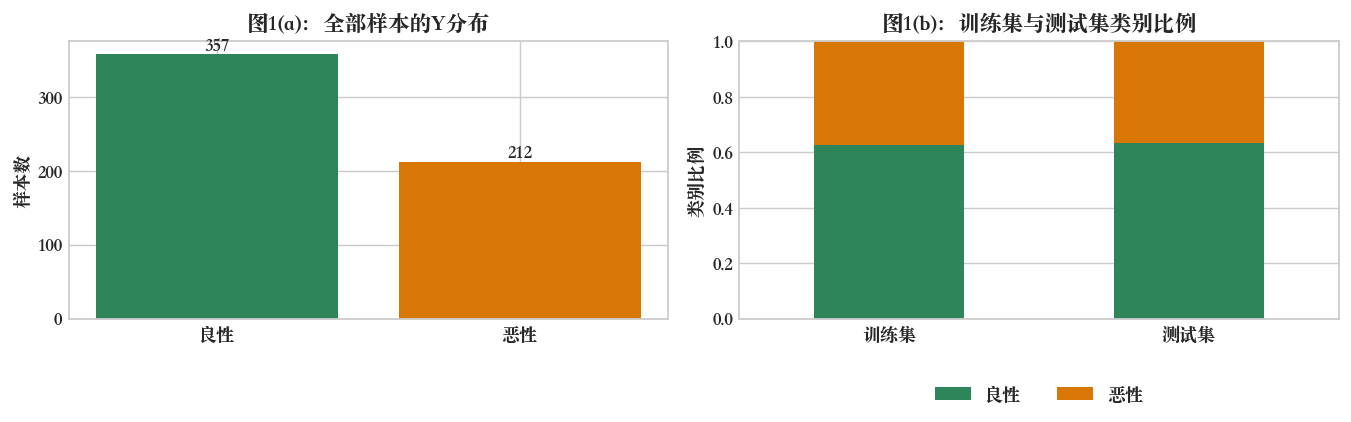

,数据段,样本数,良性,恶性,恶性比例
0,全部样本,569,357,212,0.3726
1,训练集,455,285,170,0.3736
2,测试集,114,72,42,0.3684


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
counts = data["diagnosis"].value_counts().reindex(["良性", "恶性"])
axes[0].bar(counts.index, counts.values, color=[COLORS["green"], COLORS["orange"]])
axes[0].set_ylabel("样本数"); axes[0].set_title("图1(a)：全部样本的Y分布")
for i, value in enumerate(counts.values): axes[0].text(i, value + 5, str(value), ha="center")

proportions = pd.DataFrame({
    "训练集": train["target"].value_counts(normalize=True).sort_index(),
    "测试集": test["target"].value_counts(normalize=True).sort_index(),
}).T
proportions.columns = ["良性", "恶性"]
proportions.plot(kind="bar", stacked=True, ax=axes[1],
                 color=[COLORS["green"], COLORS["orange"]])
axes[1].set_ylim(0, 1); axes[1].set_ylabel("类别比例"); axes[1].set_xlabel("")
axes[1].set_title("图1(b)：训练集与测试集类别比例")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18),
               ncol=2, frameon=False)
plt.xticks(rotation=0); plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(CHART_DIR / "fig01_target_distribution.png", bbox_inches="tight"); plt.show()

split_summary = pd.DataFrame([
 {"数据段":"全部样本","样本数":len(data),"良性":int((data.target==0).sum()),"恶性":int((data.target==1).sum()),"恶性比例":data.target.mean()},
 {"数据段":"训练集","样本数":len(train),"良性":int((train.target==0).sum()),"恶性":int((train.target==1).sum()),"恶性比例":train.target.mean()},
 {"数据段":"测试集","样本数":len(test),"良性":int((test.target==0).sum()),"恶性":int((test.target==1).sum()),"恶性比例":test.target.mean()},
])
display(split_summary)

图1显示，全部样本中恶性占 37.3%，良性样本略多，但是两类样本都保留了足够数量。分层划分后，训练集和测试集的恶性比例分别为 37.4% 和 36.8%，两者差异很小，因此后续模型结果受到类别集中影响的可能性较低。在类别分布得到确认以后，还要根据描述统计和直方图判断不同特征是否存在量纲差异和偏态分布。

#### 3.1.2 描述统计与变量分布

,feature_cn,样本数,均值,标准差,最小值,中位数,最大值
0,平均半径,455.0000,14.1661,3.5791,6.9810,13.3400,28.1100
1,平均纹理,455.0000,19.4177,4.2907,9.7100,18.9000,39.2800
2,平均周长,455.0000,92.2159,24.7171,43.7900,86.1800,188.5000
3,平均面积,455.0000,659.5782,360.4187,143.5000,546.4000,"2,501.0000"
4,平均光滑度,455.0000,0.0960,0.0143,0.0625,0.0952,0.1634
5,平均紧密度,455.0000,0.1038,0.0539,0.0194,0.0923,0.3454
6,平均凹度,455.0000,0.0892,0.0817,0.0000,0.0594,0.4268
7,平均凹点数,455.0000,0.0490,0.0397,0.0000,0.0333,0.2012
8,平均对称度,455.0000,0.1815,0.0276,0.1060,0.1799,0.3040
9,平均分形维数,455.0000,0.0627,0.0070,0.0502,0.0613,0.0974


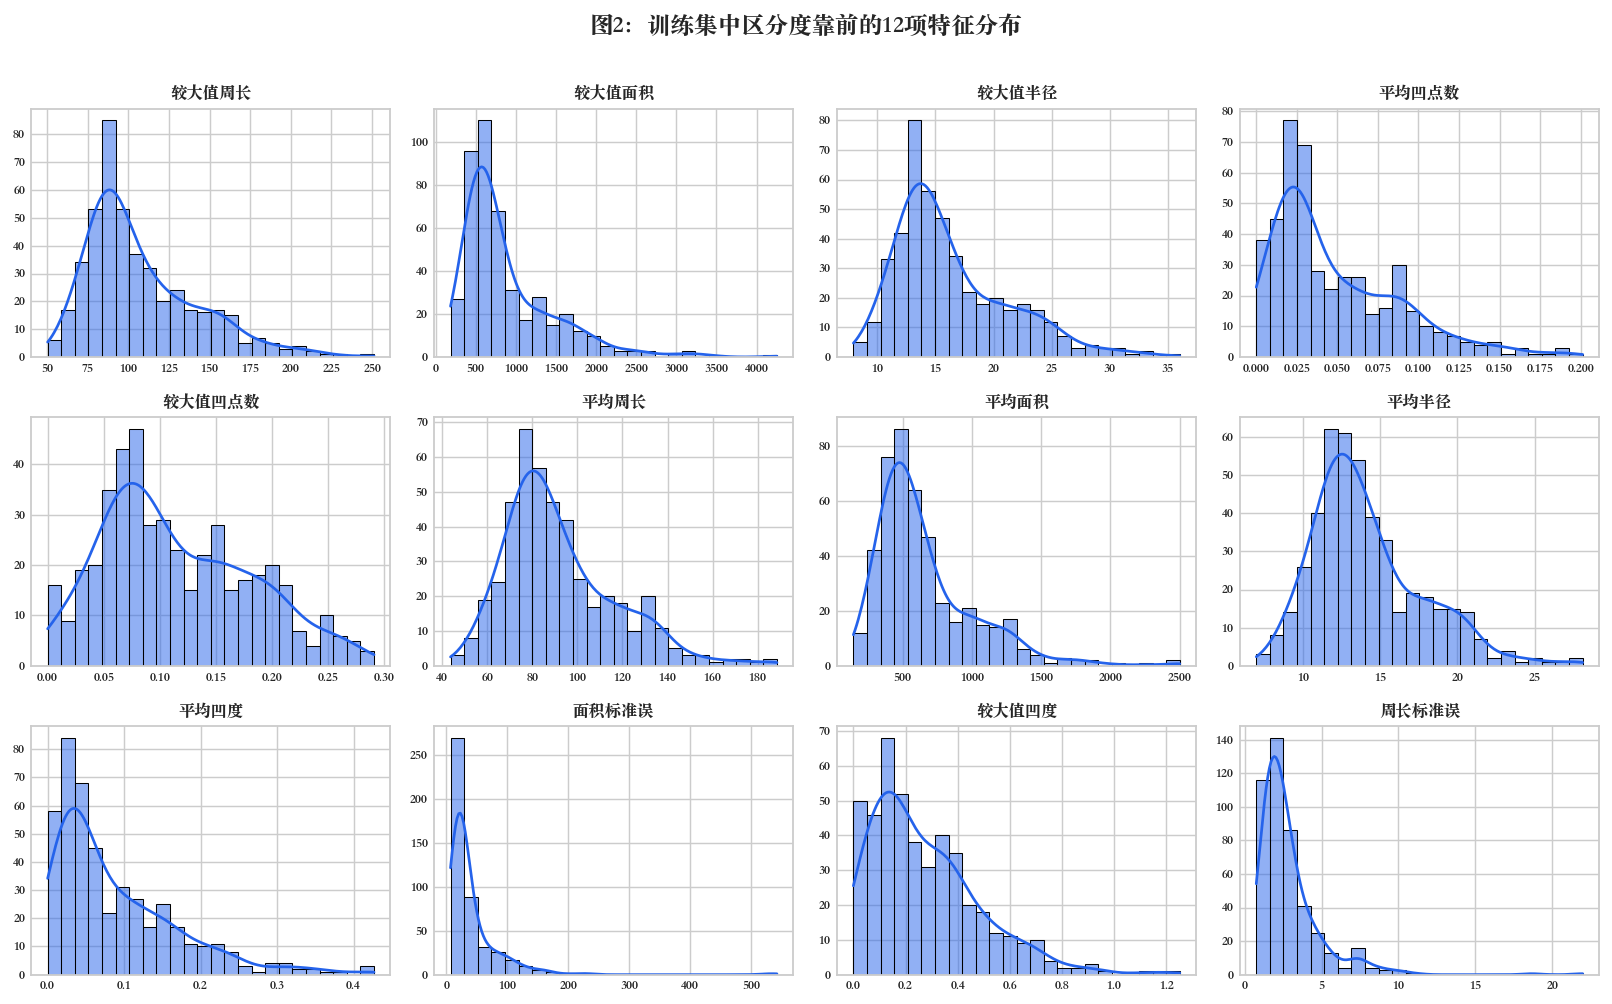

In [4]:
desc = bundle.descriptives[["feature_cn","样本数","均值","标准差","最小值","中位数","最大值"]]
display(desc)
top12 = bundle.grouped.head(12)["feature"].tolist()
fig, axes = plt.subplots(3, 4, figsize=(12.5, 7.6))
for ax, feature in zip(axes.flat, top12):
    sns.histplot(train[feature], bins=24, kde=True, ax=ax, color=COLORS["blue"])
    ax.set_title(FEATURE_NAMES[feature], fontsize=9); ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(labelsize=7)
fig.suptitle("图2：训练集中区分度靠前的12项特征分布", y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig(CHART_DIR / "fig02_feature_distributions.png", bbox_inches="tight"); plt.show()

图2和描述统计表明，不同变量的尺度差异较大，面积类变量可以达到数千，光滑度和凹度等变量通常小于1，部分特征还呈现明显右偏。如果直接把这些变量放入逻辑回归，数值尺度会影响系数估计，因此中位数填补和标准化都放在训练折内部完成。树模型依靠切分点划分样本，对统一量纲没有要求，所以继续使用特征的原始取值。

### 3.2 构造标签

标签编码会直接改变Recall和FN所指的类别。scikit-learn原数据把恶性编码为0、良性编码为1，为了让混淆矩阵中的正类直接对应恶性病例，报告将标签重新编码为恶性等于1、良性等于0。经过重编码以后，FN就表示被模型漏判为良性的恶性样本，后续召回率也可以直接解释为恶性病例的识别比例。

$$Y_i=1\quad \text{if sample }i\text{ is malignant, otherwise }Y_i=0$$

特征和诊断来自同一份患者记录，不涉及金融数据中常见的未来收益窗口，数据泄漏主要可能发生在训练集和测试集混用的环节。如果先查看测试集标签，再选择特征或调整参数，最终分数会高估模型面对新样本时的效果，因此所有依赖Y的统计都限定在训练集内计算。

In [5]:
display(data.groupby(["diagnosis", "target"]).size().rename("样本数").reset_index())

,diagnosis,target,样本数
0,恶性,1,212
1,良性,0,357


### 3.3 划分训练集与测试集

训练集用于形成模型，测试集用于检验模型面对未见患者时能否保持效果。乳腺癌数据中的患者样本没有时间先后关系，因此采用分层随机划分，将80%的样本用于特征审查、交叉验证和模型训练，剩余20%留作最终测试。测试集在特征和参数确定前保持封闭，这样得到的测试结果才可以反映模型的样本外表现。

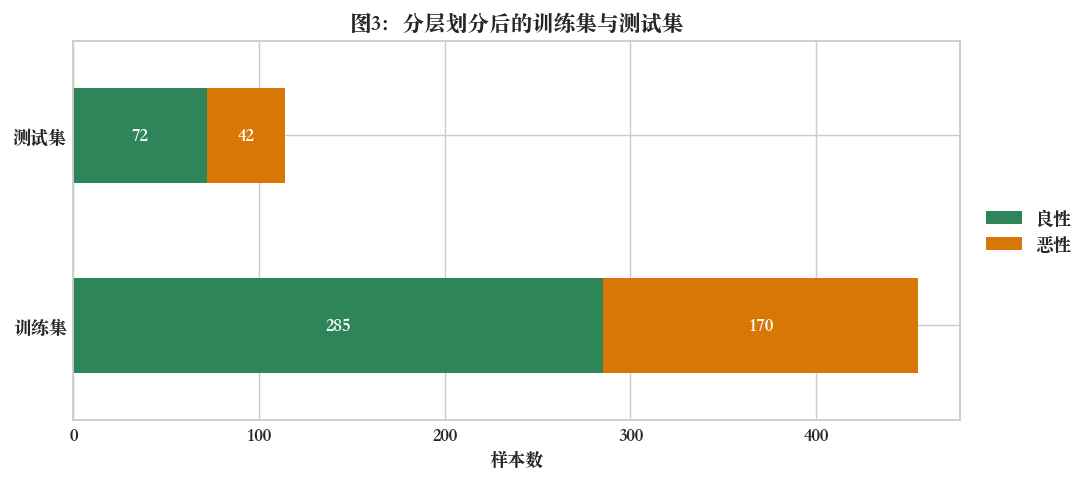

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
split_summary.set_index("数据段").loc[["训练集","测试集"],["良性","恶性"]].plot(
    kind="barh", stacked=True, ax=ax, color=[COLORS["green"], COLORS["orange"]])
ax.set_xlabel("样本数"); ax.set_ylabel(""); ax.set_title("图3：分层划分后的训练集与测试集")
for container in ax.containers: ax.bar_label(container, label_type="center", color="white", fontweight="bold")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), ncol=1, frameon=False)
plt.tight_layout(); plt.savefig(CHART_DIR / "fig03_train_test_split.png", bbox_inches="tight"); plt.show()

图3显示，训练集包含285例良性和170例恶性，测试集包含72例良性和42例恶性，两个集合的样本编号没有交集，而且恶性比例保持接近。这个结果说明样本划分没有造成明显类别偏移，因此之后的分组统计、相关性分析和特征筛选可以固定使用455条训练记录，114条测试记录继续保留到最终评价阶段。

### 3.4 选择特征

30项原始特征中包含多组相近的形态测量，如果全部放入模型，重复信息可能使系数不稳定，也会增加过度拟合的风险。特征选择因此从关联程度、折间稳定性和共线性三个方面展开，先用单变量AUC和折间波动观察变量与诊断结果的关系，再用相关系数和VIF缩减重复特征。整个筛选过程只使用训练集，测试集不参与变量取舍。

#### 3.4.1 分组描述性分析

,feature_cn,benign_mean,malignant_mean,standardized_mean_difference,direction_free_auc,cv_auc_mean,cv_auc_std,direction_consistency
0,较大值周长,87.2190,142.4654,2.5953,0.9736,0.9720,0.0166,1.0000
1,较大值面积,561.8123,"1,441.7206",2.2145,0.9682,0.9679,0.0186,1.0000
2,较大值半径,13.4114,21.2806,2.5508,0.9690,0.9675,0.0191,1.0000
3,平均凹点数,0.0253,0.0888,2.5354,0.9636,0.9640,0.0302,1.0000
4,较大值凹点数,0.0749,0.1835,2.6250,0.9627,0.9636,0.0335,1.0000
5,平均周长,78.1045,115.8732,2.2694,0.9457,0.9444,0.0286,1.0000
6,平均面积,463.8568,987.6994,2.0439,0.9373,0.9364,0.0304,1.0000
7,平均半径,12.1555,17.5368,2.1912,0.9368,0.9363,0.0312,1.0000
8,平均凹度,0.0461,0.1614,1.9323,0.9327,0.9336,0.0505,1.0000
9,面积标准误,21.3519,74.6864,1.3022,0.9209,0.9234,0.0161,1.0000


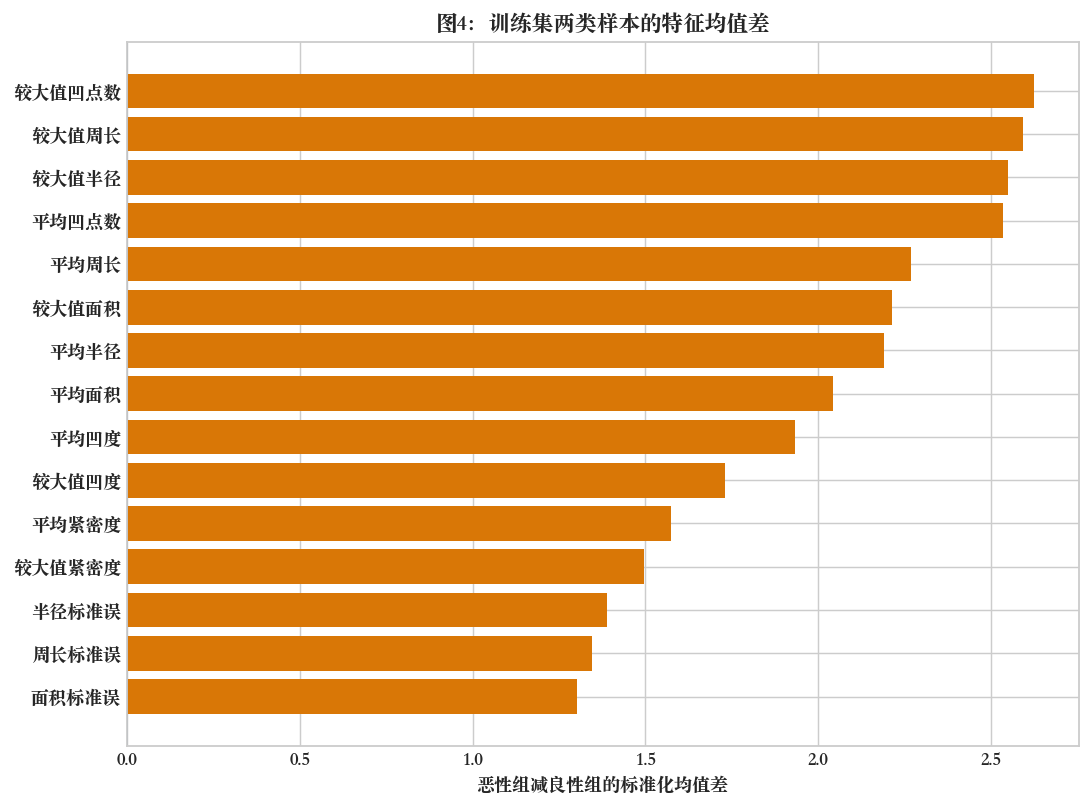

In [7]:
display(bundle.grouped[["feature_cn","benign_mean","malignant_mean",
 "standardized_mean_difference","direction_free_auc","cv_auc_mean",
 "cv_auc_std","direction_consistency"]].head(15))
plot_grouped = bundle.grouped.head(15).sort_values("standardized_mean_difference")
fig, ax = plt.subplots(figsize=(8.5, 6.3))
ax.barh(plot_grouped.feature_cn, plot_grouped.standardized_mean_difference,
        color=[COLORS["orange"] if v>0 else COLORS["green"] for v in plot_grouped.standardized_mean_difference])
ax.axvline(0, color=COLORS["gray"], lw=1)
ax.set_xlabel("恶性组减良性组的标准化均值差"); ax.set_title("图4：训练集两类样本的特征均值差")
plt.tight_layout(); plt.savefig(CHART_DIR / "fig04_grouped_difference.png", bbox_inches="tight"); plt.show()

图4比较了恶性组与良性组的标准化均值差，其中较大值周长、较大值面积、较大值半径和凹点相关变量的差异最明显，恶性组均值普遍更高。由此可以看出，肿块尺寸、边界和凹陷程度与诊断结果具有较强联系。但是，周长、面积和半径很可能描述了相近的形态特征，后续还要通过相关系数判断这些变量是否提供了重复信息。

#### 3.4.2 相关性与五折稳定性

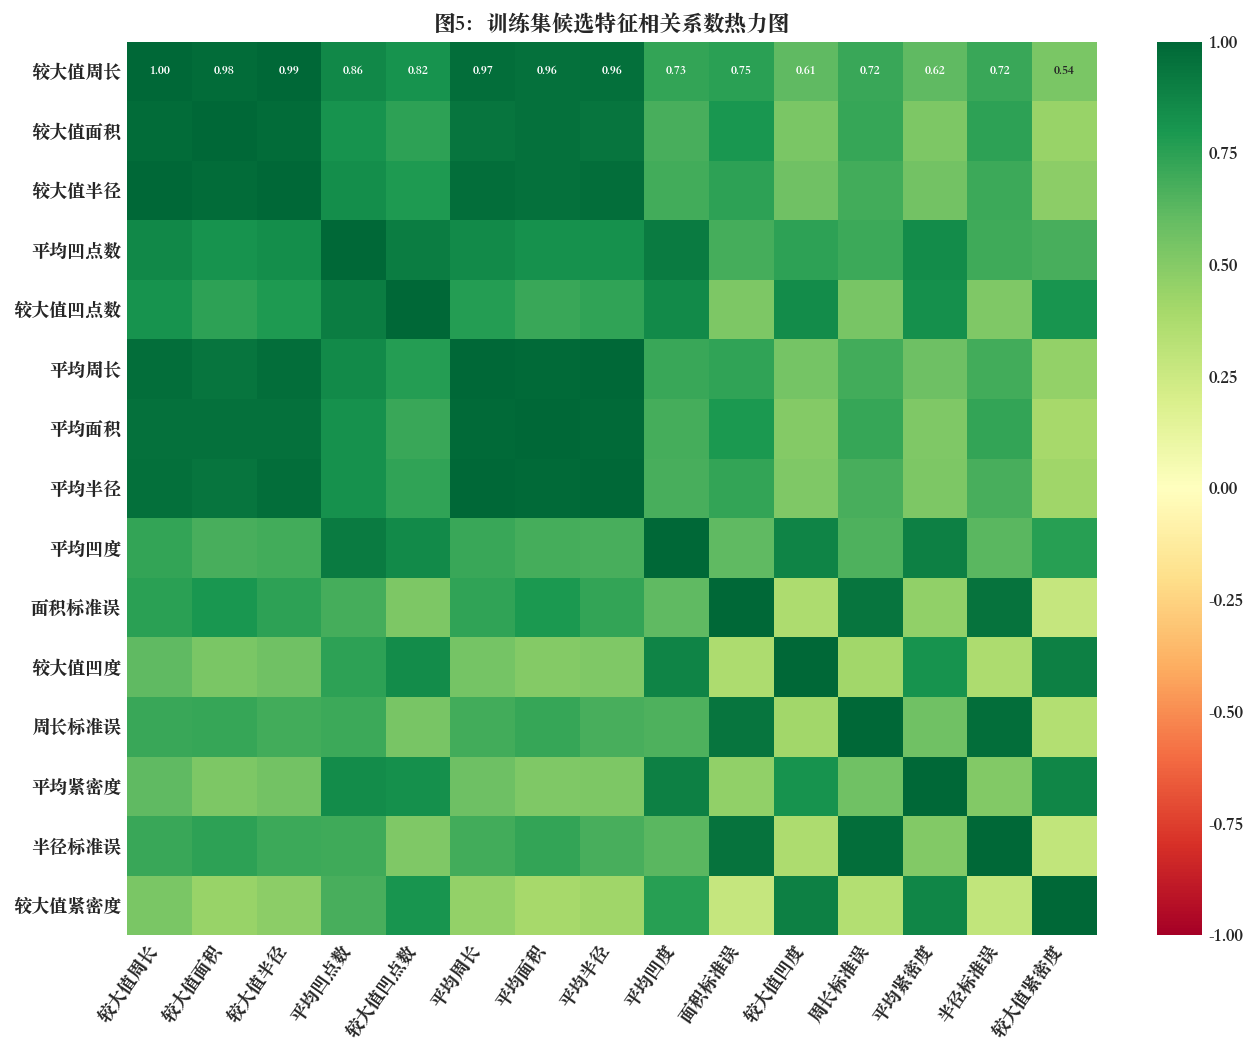

In [8]:
heat_features = bundle.grouped.head(15)["feature"].tolist()
fig, ax = plt.subplots(figsize=(10.5, 8.2))
sns.heatmap(train[heat_features].corr(), cmap="RdYlGn", center=0, vmin=-1, vmax=1,
 annot=True, fmt=".2f", xticklabels=[FEATURE_NAMES[f] for f in heat_features],
 yticklabels=[FEATURE_NAMES[f] for f in heat_features], annot_kws={"fontsize":7}, ax=ax)
ax.set_title("图5：训练集候选特征相关系数热力图")
plt.xticks(rotation=55, ha="right"); plt.yticks(rotation=0); plt.tight_layout()
plt.savefig(CHART_DIR / "fig05_correlation_heatmap.png", bbox_inches="tight"); plt.show()

图5显示，半径、周长和面积的平均值或较大值之间具有很高的相关性，凹度与凹点数也形成了明显的相关组，这与图4中多项尺寸变量同时排在前列的结果一致。如果把这些变量全部输入模型，同一种形态信息会被重复计算，逻辑回归系数也容易随样本变化。相关系数达到0.90的变量组因此只保留一项，剩余候选特征再通过五折结果检验方向是否稳定。

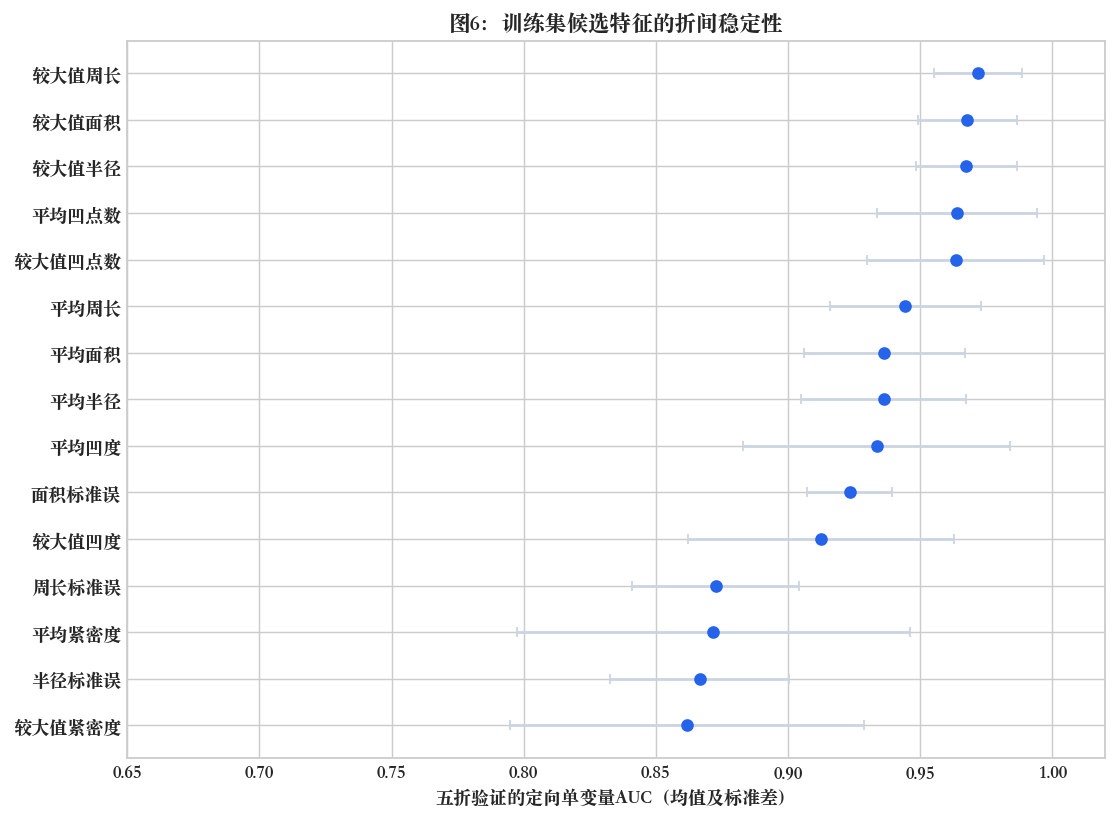

In [9]:
stable = bundle.grouped.head(15).sort_values("cv_auc_mean")
fig, ax = plt.subplots(figsize=(8.7, 6.4))
ax.errorbar(stable.cv_auc_mean, stable.feature_cn, xerr=stable.cv_auc_std,
            fmt="o", color=COLORS["blue"], ecolor=COLORS["light"], capsize=3)
ax.axvline(0.5, color=COLORS["gray"], ls="--"); ax.set_xlim(0.65, 1.02)
ax.set_xlabel("五折验证的定向单变量AUC（均值及标准差）")
ax.set_title("图6：训练集候选特征的折间稳定性")
plt.tight_layout(); plt.savefig(CHART_DIR / "fig06_feature_stability.png", bbox_inches="tight"); plt.show()

图6给出了候选变量在五个训练折中的单变量AUC，前15项变量的方向一致率均为100%，其中较大值周长的平均AUC约为0.972，而且误差线较短。这个结果说明候选变量在训练集内部没有出现明显的方向反转，关联关系具有一定稳定性。由于多个变量仍可能共同造成线性共线性，最终组合还要经过VIF检查，测试集则继续留到模型完成以后使用。

#### 3.4.3 最终特征、箱线图与VIF

,feature_cn,reason,selected_final
0,较大值周长,五折区分度和方向稳定性靠前，且未与已选变量高度重复,True
1,较大值面积,与已保留的较大值周长高度相关,False
2,较大值半径,与已保留的较大值周长高度相关,False
3,平均凹点数,训练集VIF=14.09，迭代删除,False
4,较大值凹点数,与已保留的平均凹点数高度相关,False
5,平均周长,与已保留的较大值周长高度相关,False
6,平均面积,与已保留的较大值周长高度相关,False
7,平均半径,与已保留的较大值周长高度相关,False
8,平均凹度,与已保留的平均凹点数高度相关,False
9,面积标准误,五折区分度和方向稳定性靠前，且未与已选变量高度重复,True


,feature_cn,vif
3,平均紧密度,3.8431
2,较大值凹度,3.6475
0,较大值周长,3.5338
1,面积标准误,2.6134
4,凹点数标准误,1.8241
5,较大值纹理,1.2426


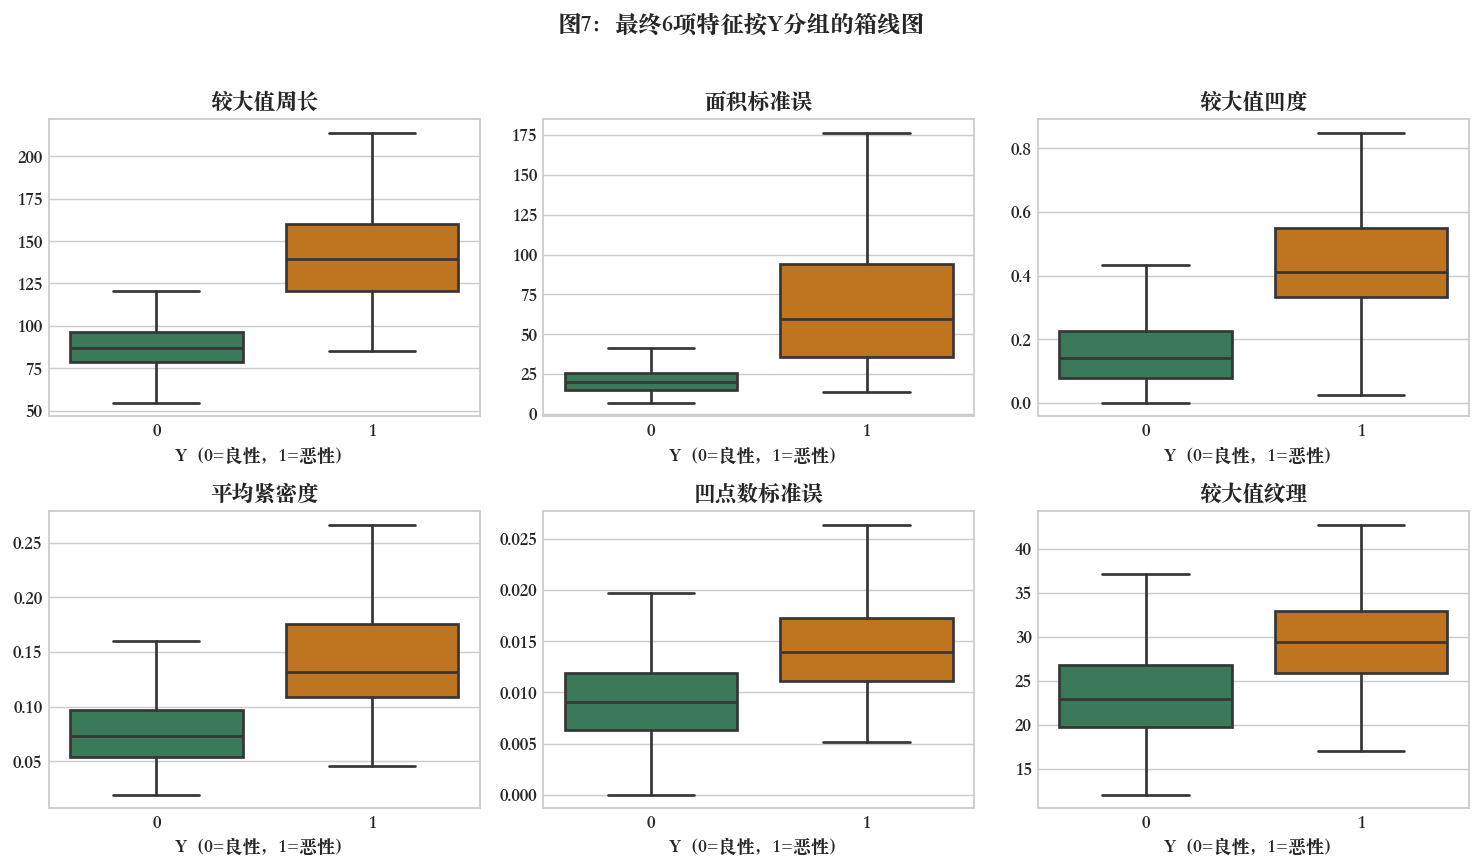

In [10]:
selection_show = bundle.decisions.loc[
 bundle.decisions.selected_final | bundle.decisions.reason.str.contains("高度相关|VIF", regex=True),
 ["feature_cn","reason","selected_final"]]
display(selection_show)
display(bundle.vif[["feature_cn","vif"]].sort_values("vif", ascending=False))
fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.5))
for ax, feature in zip(axes.flat, selected):
    sns.boxplot(data=train, x="target", y=feature, ax=ax,
                palette=[COLORS["green"], COLORS["orange"]], showfliers=False)
    ax.set_title(FEATURE_NAMES[feature]); ax.set_xlabel("Y（0=良性，1=恶性）"); ax.set_ylabel("")
fig.suptitle("图7：最终6项特征按Y分组的箱线图", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig(CHART_DIR / "fig07_selected_boxplots.png", bbox_inches="tight"); plt.show()

经过关联分析、相关性去重和VIF检查以后，最终保留6项特征，包括较大值周长、面积标准误、较大值凹度、平均紧密度、凹点数标准误、较大值纹理。图7显示两类样本的分布仍有重叠，但是中位数和主要分布区间已经出现明显差别，说明单个变量能够提供分类信息，同时还需要结合其他变量完成判断。图8给出的最大VIF为 3.84，低于阈值5，因此这组变量可以用于后续模型比较。

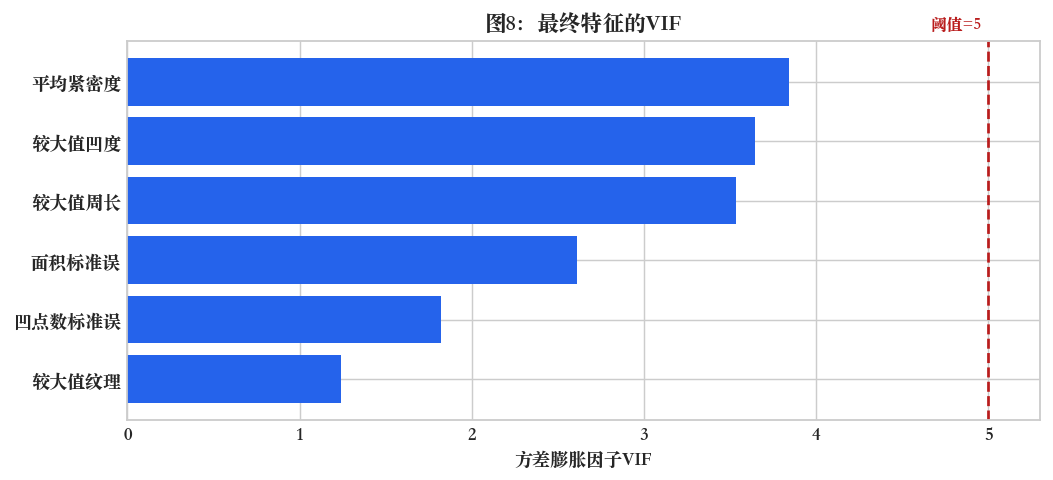

In [11]:
fig, ax = plt.subplots(figsize=(8.2, 3.8))
vif_plot = bundle.vif.sort_values("vif")
ax.barh(vif_plot.feature_cn, vif_plot.vif, color=COLORS["blue"])
ax.axvline(5, color=COLORS["red"], ls="--")
ax.set_xlim(0, 5.3)
ax.text(4.96, len(vif_plot) - 0.15, "阈值=5", color=COLORS["red"],
        ha="right", va="bottom", fontsize=9)
ax.set_xlabel("方差膨胀因子VIF"); ax.set_title("图8：最终特征的VIF")
plt.tight_layout(); plt.savefig(CHART_DIR / "fig08_vif.png", bbox_inches="tight"); plt.show()

图8中6项特征的VIF介于1.24和3.84之间，较大值周长、较大值凹度和平均紧密度仍有一定联系，但是没有达到严重共线性的程度。与直接输入30项变量相比，筛选后的组合减少了半径、周长和面积之间的重复信息，同时保留了尺寸、边界、凹度和纹理等不同形态特征，使逻辑回归系数更容易解释，也控制了模型输入的复杂度。

### 3.5 构建并训练分类模型

完成特征筛选以后，报告使用同一组6项变量训练逻辑回归、决策树、随机森林和梯度提升，由此比较线性模型、单棵树和集成模型能否从相同信息中得到不同效果。参数选择限定在455例训练样本内，并以分层五折的平均ROC-AUC作为依据。逻辑回归在Pipeline中完成填补和标准化，三种树模型则保留原始特征尺度。

,model_cn,cv_auc_mean,cv_auc_std,candidate_count,best_params
0,逻辑回归,0.9918,0.0070,6,"{""model__C"": 10.0, ""model__class_weight"": null}"
3,梯度提升,0.9900,0.0046,24,"{""model__learning_rate"": 0.05, ""model__max_dep..."
2,随机森林,0.9891,0.0051,18,"{""model__class_weight"": ""balanced_subsample"", ..."
1,决策树,0.9697,0.0115,24,"{""model__class_weight"": null, ""model__max_dept..."


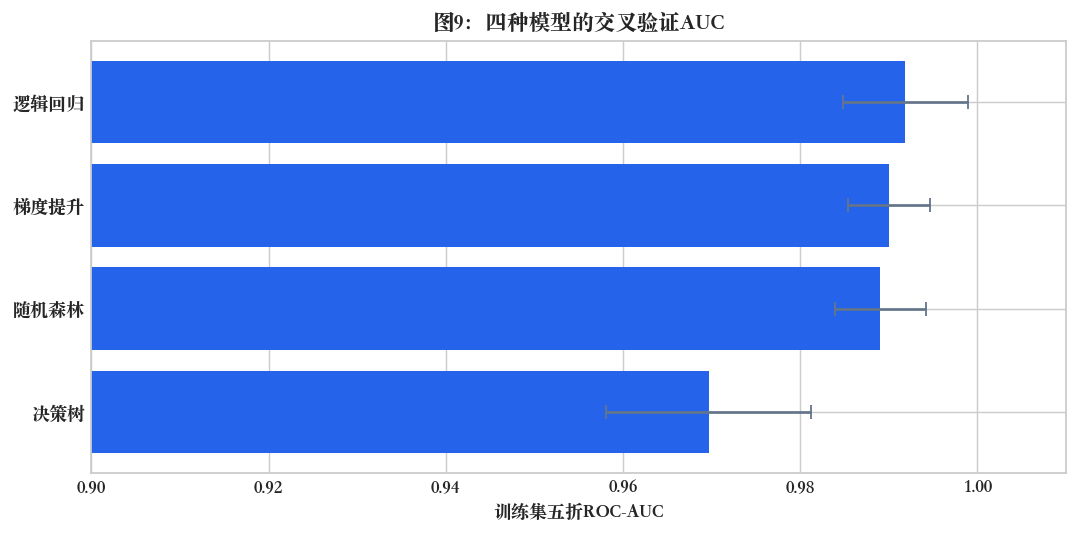

In [12]:
display(bundle.tuning[["model_cn","cv_auc_mean","cv_auc_std","candidate_count","best_params"]]
        .sort_values("cv_auc_mean", ascending=False))
fig, ax = plt.subplots(figsize=(8.4, 4.2))
tuning_plot = bundle.tuning.sort_values("cv_auc_mean")
ax.barh(tuning_plot.model_cn, tuning_plot.cv_auc_mean, xerr=tuning_plot.cv_auc_std,
        color=COLORS["blue"], ecolor=COLORS["gray"], capsize=4)
ax.axvline(0.5, color=COLORS["gray"], ls="--"); ax.set_xlim(0.90, 1.01)
ax.set_xlabel("训练集五折ROC-AUC"); ax.set_title("图9：四种模型的交叉验证AUC")
plt.tight_layout(); plt.savefig(CHART_DIR / "fig09_cross_validation.png", bbox_inches="tight"); plt.show()

图9显示，逻辑回归的五折平均AUC为0.992，随机森林和梯度提升也接近0.99，决策树约为0.970，四种模型在训练集内部都识别出了较强的分类信号，集成模型没有与逻辑回归拉开明显差距。由于特征筛选已经使用整个训练集，这些分数主要用于选择参数和观察折间波动，模型能否保持效果还要由114例独立测试样本检验。

### 3.6 对测试集进行概率预测

In [13]:
prediction_wide = (bundle.predictions
 .assign(model_cn=lambda x: x["model"].map(MODEL_NAMES))
 .pivot(index=["sample_id","target"], columns="model_cn", values="probability")
 .reset_index().merge(data[["sample_id","diagnosis"]], on="sample_id", how="left"))
display(prediction_wide.head(12))

,sample_id,target,决策树,梯度提升,逻辑回归,随机森林,diagnosis
0,5,1,1.0000,0.9152,0.9991,0.9093,恶性
1,6,1,0.8000,0.5275,0.4673,0.4985,恶性
2,8,1,0.5000,0.6182,0.8511,0.6726,恶性
3,15,1,0.8000,0.8586,0.9735,0.7914,恶性
4,21,0,0.0000,0.0048,0.0048,0.0194,良性
5,23,1,1.0000,0.9324,0.9392,0.8834,恶性
6,35,1,1.0000,0.9919,0.9926,0.9907,恶性
7,40,1,0.5000,0.6342,0.4191,0.5310,恶性
8,61,0,0.0000,0.0153,0.0001,0.0094,良性
9,65,1,0.5000,0.9198,0.9550,0.8519,恶性


四个模型都先输出测试样本属于恶性的概率，这些概率保留了样本之间的风险顺序，因此可以直接用于计算AUC。为了进一步统计具体的漏判和误判，报告统一采用0.5作为分类阈值，将概率转换为0或1。概率结果用于评价整体排序，类别结果用于生成混淆矩阵，两种口径结合以后才能看清模型分数和实际错判之间的关系。

### 3.7 评估模型

,model_cn,roc_auc,auc_ci_low,auc_ci_high,pr_auc,accuracy,balanced_accuracy,precision,recall,specificity,f1,brier,tn,fp,fn,tp
0,逻辑回归,0.9937,0.9832,0.9997,0.9897,0.9474,0.9335,0.9737,0.8810,0.9861,0.9250,0.0339,71,1,5,37
2,随机森林,0.9937,0.9812,1.0000,0.9909,0.9474,0.9335,0.9737,0.8810,0.9861,0.9250,0.0348,71,1,5,37
3,梯度提升,0.9921,0.9747,1.0000,0.9897,0.9561,0.9454,0.9744,0.9048,0.9861,0.9383,0.0322,71,1,4,38
1,决策树,0.9721,0.9345,0.9957,0.9544,0.9474,0.9484,0.9091,0.9524,0.9444,0.9302,0.0548,68,4,2,40


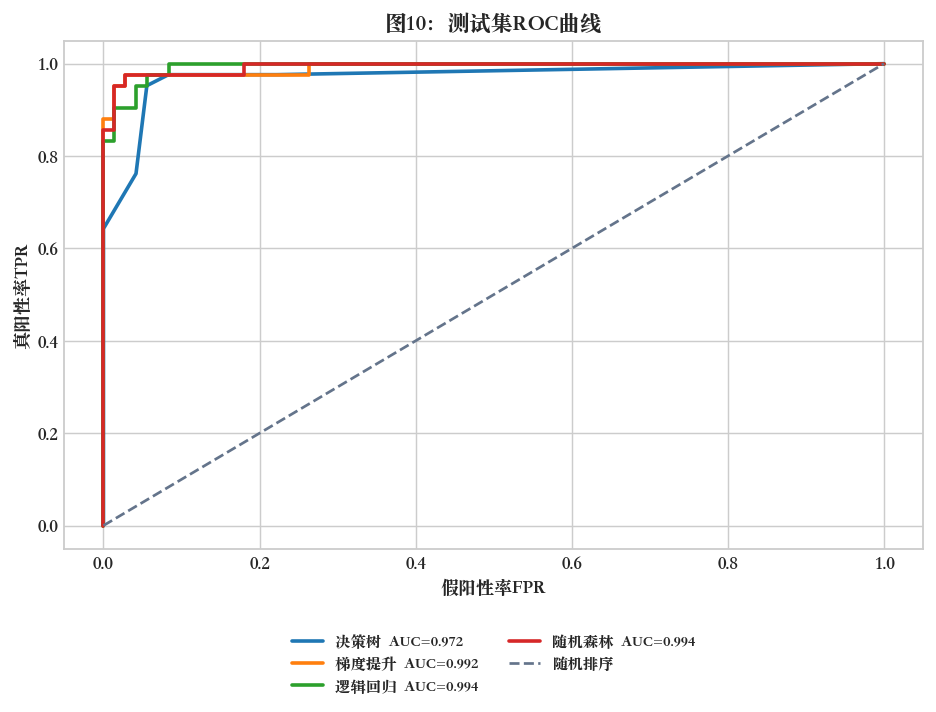

In [14]:
metrics = bundle.metrics.sort_values("roc_auc", ascending=False)
display(metrics[["model_cn","roc_auc","auc_ci_low","auc_ci_high","pr_auc","accuracy",
 "balanced_accuracy","precision","recall","specificity","f1","brier","tn","fp","fn","tp"]])
fig, ax = plt.subplots(figsize=(7.3, 6.2))
for key, frame in bundle.roc_points.groupby("model"):
    auc = metrics.loc[metrics.model==key, "roc_auc"].iloc[0]
    ax.plot(frame.fpr, frame.tpr, lw=2, label=f"{MODEL_NAMES[key]}  AUC={auc:.3f}")
ax.plot([0,1],[0,1], ls="--", color=COLORS["gray"], label="随机排序")
ax.set_xlabel("假阳性率FPR"); ax.set_ylabel("真阳性率TPR"); ax.set_title("图10：测试集ROC曲线")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2,
          fontsize=8.5, frameon=False)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(CHART_DIR / "fig10_roc.png", bbox_inches="tight"); plt.show()

图10中的四条ROC曲线都靠近左上角，说明模型能够把大多数恶性样本排在良性样本之前。逻辑回归和随机森林的测试AUC均为 0.994，梯度提升为 0.992，决策树为 0.972。前三种模型只相差0.002，而且置信区间高度重叠，因此无法根据千分位差别形成稳定排名。AUC没有给出固定阈值下的错误数量，下一部分继续结合混淆矩阵比较漏判和误判。

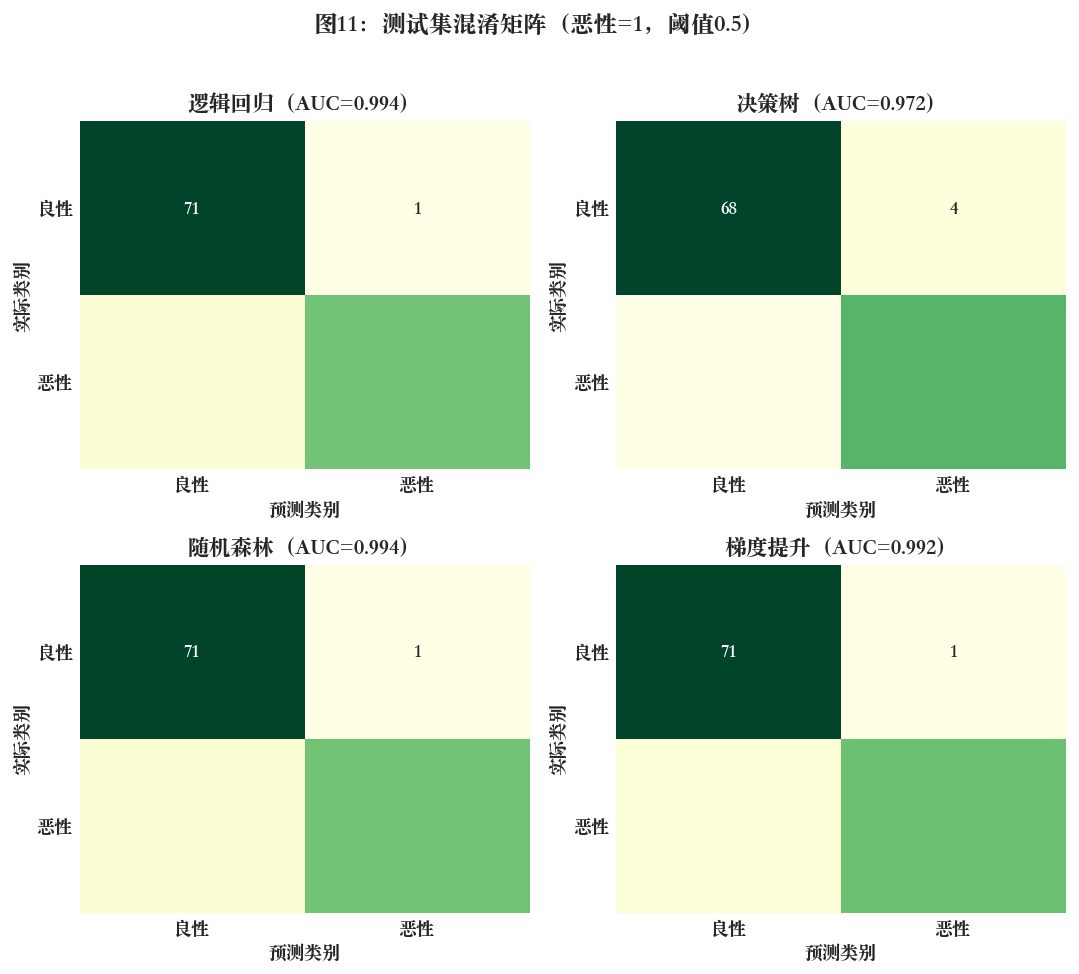

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(8.4, 7.3))
for ax, key in zip(axes.flat, MODEL_NAMES):
    row = metrics.loc[metrics.model==key].iloc[0]
    cm = np.array([[row.tn,row.fp],[row.fn,row.tp]], dtype=int)
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGn", cbar=False, ax=ax)
    ax.set_title(f"{MODEL_NAMES[key]}（AUC={row.roc_auc:.3f}）")
    ax.set_xlabel("预测类别"); ax.set_ylabel("实际类别")
    ax.set_xticklabels(["良性","恶性"]); ax.set_yticklabels(["良性","恶性"], rotation=0)
fig.suptitle("图11：测试集混淆矩阵（恶性=1，阈值0.5）", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig(CHART_DIR / "fig11_confusion_matrices.png", bbox_inches="tight"); plt.show()

图11补充了AUC没有直接呈现的错判数量。阈值取0.5时，梯度提升识别出38例恶性，漏掉4例，同时把1例良性误判为恶性，恶性召回率为 90.5%，特异度为 98.6%。决策树只漏掉2例恶性，但是产生了4例假阳性。由此可见，降低漏诊和减少良性误判会形成不同的模型选择，具体使用哪一种模型还要结合两类错误的实际代价。

#### 3.7.1 计算核对

In [16]:
display(pd.DataFrame([
 {"检查":"scikit-learn AUC","结果":bundle.controls["sklearn_auc"]},
 {"检查":"Mann-Whitney秩公式AUC","结果":bundle.controls["mann_whitney_auc"]},
 {"检查":"两种AUC绝对差","结果":bundle.controls["auc_formula_absolute_difference"]},
 {"检查":"随机打乱训练标签500次的平均测试AUC","结果":bundle.controls["permuted_label_auc_mean"]},
 {"检查":"训练测试样本编号交集","结果":bundle.controls["train_test_sample_overlap"]},
]))

,检查,结果
0,scikit-learn AUC,0.9937
1,Mann-Whitney秩公式AUC,0.9937
2,两种AUC绝对差,0.0000
3,随机打乱训练标签500次的平均测试AUC,0.5030
4,训练测试样本编号交集,0.0000


为了排除AUC方向写反或训练测试样本混用造成的高分，报告又使用Mann-Whitney秩公式独立复算逻辑回归AUC，并进行500次随机标签对照。两种AUC计算结果完全一致，随机标签的平均AUC为 0.503，训练集与测试集的样本编号交集为0。这些结果说明当前计算链条可以正常工作，但是公开数据上的内部检验仍然不能代替外部医院数据验证。

### 3.8 特征系数与重要性

,feature,feature_cn,coefficient
0,worst perimeter,较大值周长,4.0054
1,area error,面积标准误,3.6838
5,worst texture,较大值纹理,1.7842
2,worst concavity,较大值凹度,1.4580
3,mean compactness,平均紧密度,0.4369
4,concave points error,凹点数标准误,-0.3740


,model,model_cn,feature,feature_cn,importance
0,decision_tree,决策树,worst perimeter,较大值周长,0.8879
3,decision_tree,决策树,mean compactness,平均紧密度,0.0636
5,decision_tree,决策树,worst texture,较大值纹理,0.0446
1,decision_tree,决策树,area error,面积标准误,0.0038
2,decision_tree,决策树,worst concavity,较大值凹度,0.0000
4,decision_tree,决策树,concave points error,凹点数标准误,0.0000
12,gradient_boosting,梯度提升,worst perimeter,较大值周长,0.7981
14,gradient_boosting,梯度提升,worst concavity,较大值凹度,0.0693
17,gradient_boosting,梯度提升,worst texture,较大值纹理,0.0471
13,gradient_boosting,梯度提升,area error,面积标准误,0.0442


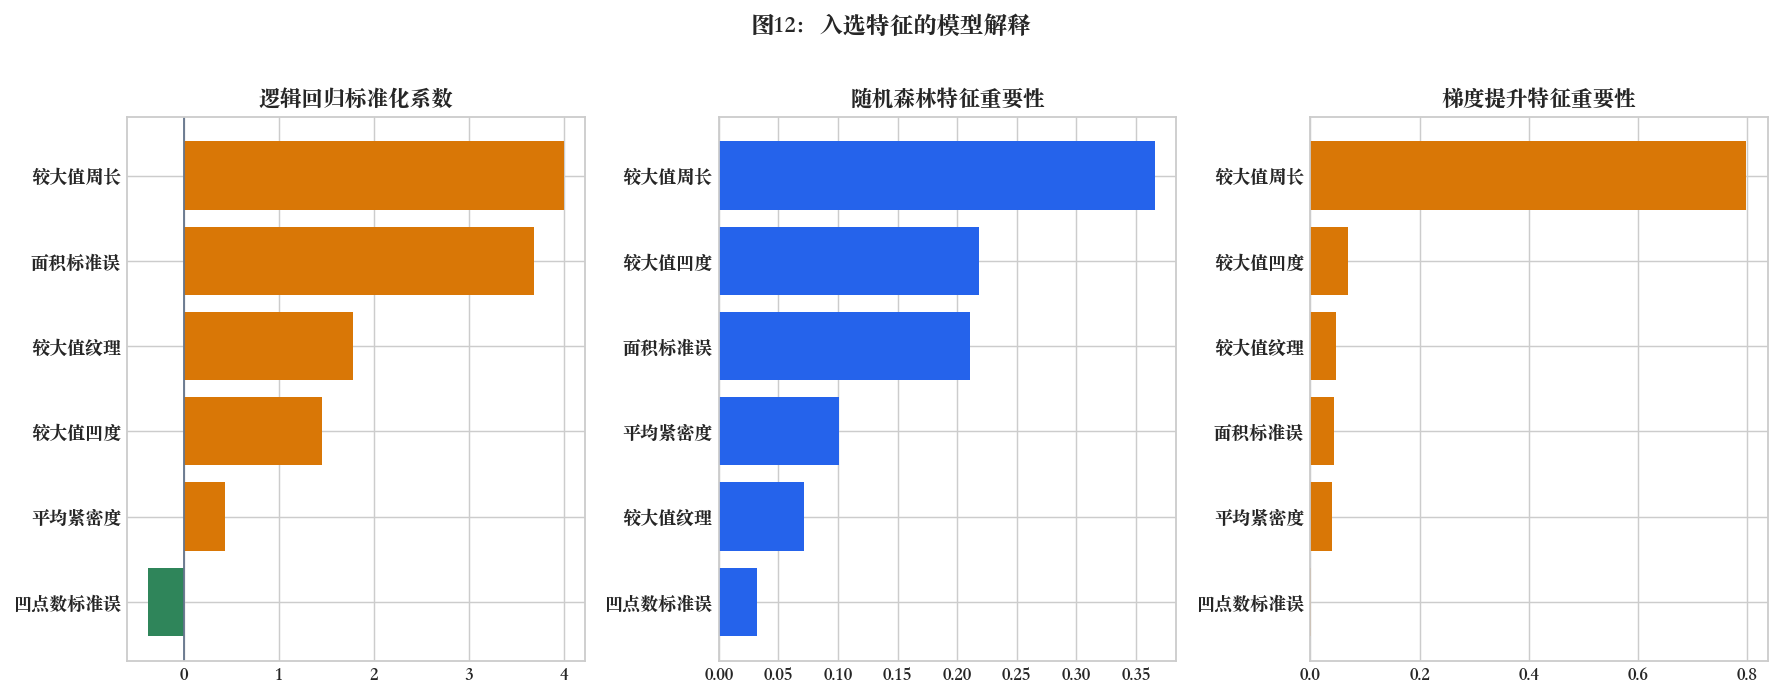

In [17]:
display(bundle.coefficients.sort_values("coefficient", key=np.abs, ascending=False))
display(bundle.importances.sort_values(["model_cn","importance"], ascending=[True,False]))
fig, axes = plt.subplots(1, 3, figsize=(13.8, 5.2))
coef = bundle.coefficients.sort_values("coefficient")
axes[0].barh(coef.feature_cn, coef.coefficient,
 color=[COLORS["orange"] if v>0 else COLORS["green"] for v in coef.coefficient])
axes[0].axvline(0, color=COLORS["gray"], lw=1); axes[0].set_title("逻辑回归标准化系数")
for ax, key in zip(axes[1:], ["random_forest","gradient_boosting"]):
    imp = bundle.importances[bundle.importances.model==key].sort_values("importance")
    ax.barh(imp.feature_cn, imp.importance,
            color=COLORS["blue"] if key=="random_forest" else COLORS["orange"])
    ax.set_title(f"{MODEL_NAMES[key]}特征重要性")
fig.suptitle("图12：入选特征的模型解释", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig(CHART_DIR / "fig12_feature_importance.png", bbox_inches="tight"); plt.show()

图12显示，四种模型的结构虽然不同，但是都较多使用肿块尺寸和边界信息。逻辑回归中，较大值周长、较大值纹理和凹点数标准误的标准化系数为正，随机森林和梯度提升的切分也较多依赖较大值周长，这与图4中的组间差异结果相互印证。系数和重要性反映模型如何利用这些变量，不能进一步解释变量与疾病之间的医学因果关系。

### 3.9 四种模型对比

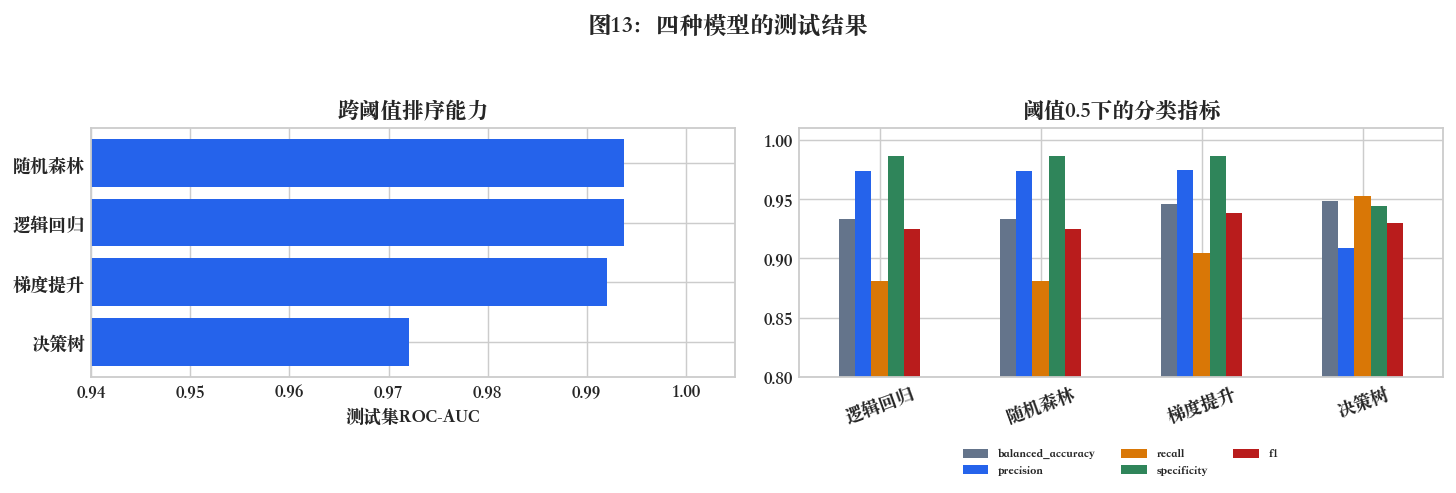

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11.3, 4.8))
ordered = metrics.sort_values("roc_auc")
axes[0].barh(ordered.model_cn, ordered.roc_auc, color=COLORS["blue"])
axes[0].set_xlim(0.94, 1.005); axes[0].set_xlabel("测试集ROC-AUC")
axes[0].set_title("跨阈值排序能力")
metrics.set_index("model_cn")[["balanced_accuracy","precision","recall","specificity","f1"]].plot(
 kind="bar", ax=axes[1], color=["#64748B","#2563EB","#D97706","#2F855A","#B91C1C"])
axes[1].set_ylim(0.80,1.01); axes[1].set_xlabel(""); axes[1].set_title("阈值0.5下的分类指标")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.24),
               fontsize=7, ncol=3, frameon=False)
plt.xticks(rotation=20)
fig.suptitle("图13：四种模型的测试结果", y=0.98, fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.11, 1, 0.94])
plt.savefig(CHART_DIR / "fig13_model_comparison.png", bbox_inches="tight"); plt.show()

图13将AUC与0.5阈值下的分类指标放在一起比较。逻辑回归和随机森林的AUC并列最高，决策树的Balanced Accuracy为 0.948，恶性召回率为 0.952，均为四种模型中的最高值，梯度提升的F1为 0.938，Brier为 0.032，在这两项上表现更好。四种模型在排序能力和错判结构上各有差异，因此模型选择需要结合漏诊和误诊的相对代价，单独比较一项分数无法得到完整结论。

### 3.10 保存结果

为了使Notebook中的结果能够重新运行和核对，分析过程保存了冻结数据、质量检查、描述统计、特征筛选、VIF、参数、预测、ROC点和评价指标。数据表位于 data/task5/breast_cancer/results，四个模型位于 artifacts/models/task5/breast_cancer，13幅图位于 artifacts/charts/task5/breast_cancer。manifest.json同时记录原标签含义、重编码方式、样本划分和数据哈希，后续可以据此确认数据版本和研究口径。

In [19]:
saved = []
for folder in [RESULT_DIR, MODEL_DIR, CHART_DIR]:
    for path in sorted(folder.glob("*")):
        if path.is_file():
            saved.append({"文件":str(path.relative_to(ROOT)), "KB":round(path.stat().st_size/1024,1)})
display(pd.DataFrame(saved))

,文件,KB
0,data/task5/breast_cancer/results/dashboard_cla...,0.2000
1,data/task5/breast_cancer/results/dashboard_fea...,1.4000
2,data/task5/breast_cancer/results/dashboard_lr_...,0.8000
3,data/task5/breast_cancer/results/dashboard_mod...,1.8000
4,data/task5/breast_cancer/results/dashboard_rf_...,0.8000
5,data/task5/breast_cancer/results/dashboard_sel...,1.3000
6,data/task5/breast_cancer/results/dashboard_sum...,0.2000
7,data/task5/breast_cancer/results/dashboard_thr...,1.4000
8,data/task5/breast_cancer/results/data_quality.csv,0.2000
9,data/task5/breast_cancer/results/dataset.csv,130.1000


## 四、总结与反思

### 4.1 本题得到的结果

在114例独立测试样本中，逻辑回归和随机森林的AUC均约为0.994，梯度提升约为0.992，决策树约为0.972，其余455例患者用于特征筛选、参数选择和模型训练。四种模型都取得了较高分数，其中逻辑回归的结构最简单，结果却与随机森林非常接近。图4和图7已经显示细胞核周长、凹度和纹理在恶性组与良性组之间存在明显分布差异，因此本题的高AUC主要来自X中包含了能够区分Y的形态信息，模型复杂度对结果的影响相对有限。

这些结果来自公开教学数据的内部测试，数据没有覆盖外部医院、不同设备和不同人群，阈值选择也没有引入漏诊与误诊的实际成本，所以报告中的模型只能用于说明分类流程。乳腺癌数据具有较清楚的X与Y关系，可以展示数据检查、特征工程和模型评估怎样连接起来；真实交易数据中的未来收益同时受到市场环境、政策变化和公司事件影响，X与Y的关系更容易随时间变化。基于这一差异，下一节回顾本题前期使用交易数据进行机器学习预测的结果。

### 4.2 此前使用交易数据进行机器学习预测的结果

最初的交易数据预测采用月末截面选股思路，样本来自冻结的沪深A股股票池，Y表示未来60个交易日收益处于当月截面的前30%或后30%，中间40%的股票不进入分类，X包括历史价格、成交量和技术指标。2018至2024年共有4349条拟合记录，2025年测试集包含9个月末和525条记录。随机森林的测试AUC最高，为0.533，移动块Bootstrap区间约为[0.298, 0.684]。这个结果只比随机排序略高，而且置信区间跨过0.5。虽然表面上有525条测试记录，但是这些记录集中在9个月末，同一个月的股票共享相近的市场环境，真正独立的时间状态远少于记录数量，因此结果具有较大不确定性。

考虑到60日收益窗口较长，第二种定义将Y改为未来20个交易日收益是否大于0，并在X中增加个股相对强弱和市场状态。2018至2024年有7867条拟合记录，2025年测试集为1065条。逻辑回归的测试AUC为0.529，95%区间约为[0.499, 0.587]，决策树和随机森林均低于0.5。缩短预测期限并增加市场变量以后，线性模型只保留了很弱的排序优势，非线性模型在验证期出现的改善也没有延续到测试期。这个Y还混入了市场整体方向，大盘普涨和个股相对表现较好都会被记为正类，因此它与实际选股问题存在一定偏差。

为了减少不同公司之间的差异，第三种定义把对象收缩为宁德时代，并将Y改为未来20个交易日收益能否超过沪深300。数据按周取样，清除跨越时间边界的标签以后，训练集有318条记录，2025年测试集只有48条。决策树的测试AUC为0.524，移动块Bootstrap区间为[0.349, 0.691]。单股分析减少了公司之间的异质性，也使可用样本大幅减少；相邻周的20日收益窗口高度重叠，48条测试记录粗略只相当于12个不重叠窗口。三种定义经过调整以后，最高测试AUC仍然只有0.533、0.529和0.524，现有技术指标没有在样本外时间段形成稳定预测能力，因此还要通过独立复算、对照标签和跨时段结果判断低AUC来自计算问题还是数据本身。

### 4.3 失败结果的含义与改进

#### 4.3.1 AUC接近0.5表示什么

AUC衡量模型对正类和负类的排序。随机抽取一条正类记录和一条负类记录，AUC等于模型把正类得分排在负类之前的概率。AUC为0.5时，两类记录的先后顺序接近随机排列；AUC为0.533时，100组正负样本对中大约有53.3组能够排对，只比随机排序多3.3组。这样的差距可能来自微弱关系，也可能来自有限样本中的波动，所以还要结合置信区间和跨时段表现判断。

三组交易数据预测的最高测试AUC分别为0.533、0.529和0.524，三个置信区间都覆盖0.5，模型之间也没有形成稳定次序。随机森林在60日截面排名中最高，逻辑回归在20日绝对涨跌中最高，单股案例则由决策树略高。如果一组因子包含稳定关系，相同方向通常会在多个时间段重复出现；现有结果只说明训练样本中可能存在少量线索，测试结果还不足以证明这些线索可以延续到新的市场阶段。

#### 4.3.2 低AUC是否来自计算错误

低AUC既可能来自程序实现错误，也可能来自真实收益标签中缺少稳定信息，因此报告从时间边界、计算公式、随机标签、人工标签和预测口径五个方面进行核对。时间边界检查可以发现未来收益是否被错误放入前一分段，独立公式可以检查AUC方向，对照标签则可以判断模型管线在有信息和无信息数据上是否表现正常。

| 核对项目 | 结果 | 能排除的问题 |
|---|---|---|
| 标签与时间边界 | 标签逐行复算一致，各分段日期不重叠，跨界标签已清除 | 标签方向错误、未来收益落入前一分段 |
| AUC独立复算 | 宁德时代逻辑回归的scikit-learn AUC与Mann-Whitney秩公式均为0.368695，差值为5.55e-17 | AUC公式或正负类方向写错 |
| 随机标签 | 置换训练标签后的平均AUC为0.497 | 管线在无信息数据上虚构高AUC |
| 人工可预测标签 | 用已知特征构造标签后AUC为0.996 | 模型或评价代码完全没有学习能力 |
| 预测值口径 | AUC均使用正类概率计算，同一测试标签供所有模型使用 | 把0/1类别误当概率、模型测试口径不一致 |

核对结果显示，scikit-learn AUC与Mann-Whitney秩公式的差值只有5.55e-17，随机标签的平均AUC回到0.497，人工构造的可预测标签则达到0.996。这说明模型和评价代码在信息存在时能够学到关系，在标签被随机打乱以后也会回到随机水平。真实收益标签仍停留在0.5附近，因此低AUC不能解释为评价函数失效，后续分析转向训练期关系能否延续到测试期。

#### 4.3.3 训练期关系没有稳定延续到测试期

60日截面排名的跨期结果最能反映关系衰减。逻辑回归在2023年验证期的AUC为0.752，2024年降至0.575，2025年测试期只剩0.509；随机森林也从0.726降到0.594和0.533。早期验证结果说明价量因子曾经包含一定排序信息，但是这种优势随着时间推进逐渐减弱，到了最终测试期已经接近随机水平。

| 模型与任务 | 2023验证期 | 2024开发期 | 2025测试期 |
|---|---:|---:|---:|
| 60日截面排名（逻辑回归） | 0.752 | 0.575 | 0.509 |
| 60日截面排名（随机森林） | 0.726 | 0.594 | 0.533 |
| 20日绝对涨跌（逻辑回归） | 0.524 | 0.577 | 0.529 |
| 20日绝对涨跌（随机森林） | 0.517 | 0.577 | 0.492 |

20日绝对涨跌也出现了相似变化。随机森林在2024年开发期达到0.577，到了2025年变为0.492；逻辑回归保留了一点排序能力，但AUC只有0.529。宁德时代案例的波动更加明显，逻辑回归在2021至2024年的滚动验证AUC依次为0.719、0.550、0.537和0.543，2025年测试AUC降到0.369，随机森林的四年平均验证AUC为0.573，测试期为0.400。不同模型都出现验证期较高、测试期下降的现象，说明某一阶段有效的价量关系没有在后一阶段保持同样强度。

市场状态变化可以解释一部分跨期差异。20日绝对涨跌标签的正类比例从2018年的36.2%变到2019年的54.3%，2023年为39.5%，2024年和2025年又升到52.6%和54.7%。AUC不会由正类比例直接决定，但是这些数字说明样本经历了不同的涨跌环境。部分市场状态变量在训练期、验证期和开发期之间的KS距离达到0.33至0.40，测试期的输入分布已经发生明显变化，同时X与Y之间的对应关系也可能随政策、流动性和风险偏好改变。训练期关系失效以后，增加模型复杂度无法恢复已经消失的关联。

#### 4.3.4 因子数量不等于信息数量

前两组预测各使用20余项变量，但是多数变量来自同一组价格和成交量。1日、5日和20日收益，均线偏离、RSI和MACD都在描述历史价格，ATR、波动率和日内振幅主要描述风险状态，因此变量数量增加并没有带来同等数量的独立信息。随机森林和梯度提升可以重新组合这些变量，却无法补充数据中没有记录的估值、盈利预期和公司事件。预测期限达到20日或60日以后，这些缺失信息对收益的影响会更加明显。

宁德时代的60日贝塔说明因子关系本身也会变化，它的单变量AUC从2021年的0.672降到2022年的0.462、2023年的0.323和2024年的0.189，方向没有保持稳定。把不同市场阶段合在一起训练，可能使某一阶段的正相关与另一阶段的负相关相互抵消。后续若加入财务、估值、行业和公告变量，必须按照当时真实披露日期匹配历史数据；如果把后来发布的信息回填到更早日期，AUC可能明显升高，但是这种提高来自未来信息泄漏，无法形成可执行的交易策略。

#### 4.3.5 目标定义与有效样本仍有错位

60日截面排名与选股决策较为接近，但是月末连续样本的未来收益窗口大量重叠。2025年虽然有525条股票与月末组合记录，实际只覆盖9个月末，同一个月的股票还共享相同的宏观环境。移动块Bootstrap区间达到[0.298, 0.684]，反映出独立市场状态数量较少，因此记录数量不能直接等同于有效样本数量。

20日绝对涨跌将问题转向市场择时，市场整体上涨带来的正收益也会被记为个股预测成功，同时标签丢失了收益幅度，上涨0.1%与上涨10%都记为1，下跌0.1%与下跌10%都记为0，手续费、滑点和换手成本也没有进入标签。单股相对沪深300的定义减少了市场方向影响，但是2025年只有48条周度测试记录，20日标签约跨四周，粗略只相当于12个不重叠窗口。两种定义分别缓解了一部分问题，也引入了新的偏差和样本量限制，所以略高于0.5的AUC还不能直接转化为正收益策略。

#### 4.3.6 结论边界

现有结果支持的结论具有明确范围。在当前股票范围、时间划分和预测期限下，仅依靠价量与技术指标，还没有得到稳定的样本外排序能力。金融收益中的可预测部分较弱，公开信号还会受到交易者竞争影响，加上标签噪声、窗口重叠和市场状态变化，模型能够识别的稳定关系进一步减少。这些结果说明当前数据和目标尚未支持交易决策，但不能据此扩大到所有机器学习方法或所有金融市场。

后续改进可以先从研究问题入手。选股任务可以采用未来相对收益、连续收益率或截面排序，风险管理任务可以预测波动率、回撤或尾部损失；目标确定以后，再补充按照历史发布时间对齐的估值、财务、行业和事件变量，并扩大不同市场阶段的覆盖范围。滚动验证用于观察关系是否衰减，最终测试期继续保持封闭。如果经过这些调整以后AUC仍停留在0.5附近，就可以判断这组数据不足以支持相应交易决策，继续增加模型复杂度只会提高过度拟合风险。乳腺癌数据说明清楚的X与Y关系可以被模型识别，交易数据的结果则说明模型效果还取决于目标定义、信息覆盖和时间稳定性。